<a href="https://colab.research.google.com/github/Krunchops/GPT_scratch/blob/main/gpt_fromscratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-04-01 18:03:38--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-04-01 18:03:38 (23.0 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
import re
text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [5]:
ext = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [6]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

10


In [7]:
all_words=sorted(set(preprocessed)) #TO REMOVE DUPLICATES AND GET THEM IN ALPHABETICAL ORDER

In [9]:
vocab = {token:integer for integer,token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
      break

(',', 0)
('.', 1)
('Hello', 2)
('This', 3)
('a', 4)
('is', 5)
('test', 6)
('world', 7)


In [10]:
class Tokenizer():
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}
  def encode(self, text):
    preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [item if item in self.str_to_int
                else "<|unk|>" for item in preprocessed]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids
  def decode(self,ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    text=re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [11]:
tokenizer=Tokenizer(vocab)

In [12]:
len(vocab)

8

In [13]:
#ADDING NEW TOKENS <|UNK|> AND <|ENDOFTEXT|> TO HANDLE UNKNOWN WORDS
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)}

In [14]:
!pip install tiktoken

In [15]:
import tiktoken

In [16]:
tokenizer = tiktoken.get_encoding("gpt2")

In [19]:
#WE WILL TOKENIZE RAW TEXT NOW

In [20]:
with open('input.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

In [21]:
enc_text=tokenizer.encode(raw_text)

In [22]:
len(enc_text)

338025

In [23]:
enc_sample=enc_text[:50]

In [24]:
#FOR INPUT-TARGET
size=5
x=enc_sample[:size]
y=enc_sample[1:size+1]

In [25]:
for i in range(1, size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired) #THIS IS HOW A LLM LEARNS TO PREDICT THE NEXT WORD

[5962] ----> 22307
[5962, 22307] ----> 25
[5962, 22307, 25] ----> 198
[5962, 22307, 25, 198] ----> 8421
[5962, 22307, 25, 198, 8421] ----> 356


In [26]:
#NOW WE HAVE TO DO THE SAME AS THE ABOVE CELL FOR THE WHOLE RAW TEXT SO WE USE PYTORCH'S INBUILT DATALOADER
import torch
from torch.utils.data import DataLoader,Dataset
class GPT_dataset(Dataset):
  def __init__(self,text,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]
    self.stride=stride
    token_ids=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
    for i in range(0,len(text)-max_length,stride):
      chunk=token_ids[i:i+max_length]
      target=token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(chunk,dtype=torch.long))
      self.target_ids.append(torch.tensor(target,dtype=torch.long))
  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self,idx):
    return self.input_ids[idx],self.target_ids[idx]

In [27]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                 stride=128, shuffle=True, drop_last=True,
                 num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPT_dataset(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
dataset,
batch_size=batch_size,
shuffle=shuffle,
drop_last=drop_last,
num_workers=num_workers
    )
    drop_last=True
    return dataloader


In [28]:
with open('input.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

In [29]:
data=iter(create_dataloader_v1(raw_text,batch_size=1,max_length=6,stride=2,shuffle=False))
first=next(data)
print(first)

[tensor([[ 5962, 22307,    25,   198,  8421,   356]]), tensor([[22307,    25,   198,  8421,   356,  5120]])]


In [30]:
vocab_size = 338025
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [31]:
#FROM HERE SELF ATTENTION
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], #Your
   [0.55, 0.87, 0.66], #journey
   [0.57, 0.85, 0.64], #starts
   [0.22, 0.58, 0.33], #with
   [0.77, 0.25, 0.10], #one
   [0.05, 0.80, 0.55]] #step
)

In [32]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [33]:
d_in=3 #INPUT VECTOR DIMENSION =3(inputs tensor is 6*(3))
d_out=2 #OUTPUT VECTOR DIMENSION=2
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
#WE DO REQUIRE_GRAD=FALSE AS WE ARE NOT TRAINING RIGHT , WHEN TRAINING WE WILL SET IT TO TRUYE

In [34]:
W_query #ALL RANDOM VALUES ONLY RIGHT NOW AS IT IS NOT TRAINED

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

In [35]:
queries= inputs @ W_query

In [36]:
queries

tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])

In [37]:
keys= inputs @ W_key

In [38]:
values= inputs @ W_value

In [39]:
keys #6*2

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

In [40]:
att_score_2= queries[1].dot(keys[1])
print(att_score_2) #THIS IS THE ATTENTION SCORE FOR 2ND QUERY OF OUR INPUT

tensor(1.8524)


In [41]:
attn_scores = queries @ keys.T
print(attn_scores) #ATTENTION SCORES FOR ALL THE QUERIES

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


In [42]:
d_k=attn_scores.shape[0]

In [43]:
attn_scores=attn_scores/(d_k**0.5) #WE DIVIDE BY ROOT OF D_K AS IT HELPS TO NORMALIZE THE DATA BEFORE SENDING IT THROUGH SOFTMAX

In [44]:
attn_wts=torch.softmax(attn_scores,dim=-1)

In [45]:
attn_wts

tensor([[0.1609, 0.1919, 0.1895, 0.1524, 0.1301, 0.1753],
        [0.1586, 0.2011, 0.1977, 0.1467, 0.1185, 0.1773],
        [0.1587, 0.2007, 0.1973, 0.1470, 0.1191, 0.1772],
        [0.1628, 0.1855, 0.1838, 0.1560, 0.1388, 0.1731],
        [0.1638, 0.1829, 0.1815, 0.1573, 0.1425, 0.1720],
        [0.1612, 0.1911, 0.1888, 0.1528, 0.1311, 0.1749]])

In [46]:
context_vec=attn_wts @ values

In [47]:
context_vec #THIS CONTAINS THE EMBEDDING VECTOR OF ALL THE QUERIES AFTER GOING THROUGH SELF ATTENTION

tensor([[0.2915, 0.7857],
        [0.2955, 0.7957],
        [0.2953, 0.7952],
        [0.2886, 0.7786],
        [0.2874, 0.7757],
        [0.2912, 0.7849]])

In [48]:
#NOW WE WRITE ALL THESE STEPS OF SELF ATTENTION IN ONE CLASS
import torch.nn as nn
class SelfAttentionv1(nn.Module):
  def __init__(self,d_in,d_out):
    super().__init__()
    self.W_query=nn.Parameter(torch.randn(d_in,d_out))
    self.W_key=nn.Parameter(torch.randn(d_in,d_out))
    self.W_value=nn.Parameter(torch.randn(d_in,d_out))
  def forward(self,x):
    keys= x @ self.W_key
    queries= x @ self.W_query
    values= x @ self.W_value
    att_scores= queries @ keys.T
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    context_vec = attn_weights @ values
    return context_vec

In [49]:
import torch.nn as nn
class SelfAttentionv2(nn.Module):
  def __init__(self,d_in,d_out,qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) #nn.Linear has optimized weight initialization for non bias terms which helps in better training
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
  def forward(self,x):
    keys= x @ self.W_key
    queries= x @ self.W_query
    values= x @ self.W_value
    att_scores= queries @ keys.T
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    context_vec = attn_weights @ values
    return context_vec

In [50]:
#WE WILL USE MASKED ATTENTION WHICH MAKES OUR LLM TO NOT SEE FUTURE TOKENS SO IN ATT_wTS WE WILL MAKE THE TERMS ABOVE THE DIAGONAL TO BE ZERO
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)


tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [51]:
masked_simple= attn_wts * mask_simple

In [52]:
masked_simple

tensor([[0.1609, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1586, 0.2011, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1587, 0.2007, 0.1973, 0.0000, 0.0000, 0.0000],
        [0.1628, 0.1855, 0.1838, 0.1560, 0.0000, 0.0000],
        [0.1638, 0.1829, 0.1815, 0.1573, 0.1425, 0.0000],
        [0.1612, 0.1911, 0.1888, 0.1528, 0.1311, 0.1749]])

In [53]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4409, 0.5591, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2851, 0.3604, 0.3545, 0.0000, 0.0000, 0.0000],
        [0.2366, 0.2696, 0.2671, 0.2267, 0.0000, 0.0000],
        [0.1978, 0.2209, 0.2192, 0.1900, 0.1721, 0.0000],
        [0.1612, 0.1911, 0.1888, 0.1528, 0.1311, 0.1749]])


In [54]:
#ONE MORE THING THAT WE CAN DO IS THAT INSTEAD OF MAKING A MASKED WITH -INFITITY
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.3769,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.5187, 0.7562,   -inf,   -inf,   -inf,   -inf],
        [0.5121, 0.7464, 0.7298,   -inf,   -inf,   -inf],
        [0.2847, 0.4151, 0.4058, 0.2419,   -inf,   -inf],
        [0.2496, 0.3600, 0.3521, 0.2091, 0.1105,   -inf],
        [0.3672, 0.5375, 0.5254, 0.3136, 0.1607, 0.4489]])


In [55]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4581, 0.5419, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2988, 0.3527, 0.3485, 0.0000, 0.0000, 0.0000],
        [0.2406, 0.2638, 0.2621, 0.2334, 0.0000, 0.0000],
        [0.1986, 0.2148, 0.2136, 0.1930, 0.1800, 0.0000],
        [0.1631, 0.1839, 0.1824, 0.1570, 0.1409, 0.1728]])


In [56]:
# TO PREVENT OVERFITTING WE WILL USE DROPOUT METHOD IN THE ATTENTION WEIGHTS MATRIX WHICH WILL DROP HALF OF THE WEIGHTS (AS WE ARE CHOOSING P=0.5 THIS TIME


torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [57]:
dropout(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.7053, 0.6971, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5242, 0.4669, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3600, 0.0000],
        [0.3261, 0.3678, 0.0000, 0.3140, 0.2818, 0.3455]])

In [58]:
# now we will add this dropout and masked attention in our selfattentionv2 class
import torch.nn as nn
class SelfAttentionv2(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
    super().__init__()
    self.d_out=d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) #nn.Linear has optimized weight initialization for non bias terms which helps in better training
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout=nn.Dropout(dropout)
    self.register_buffer(
   'mask',
   torch.triu(torch.ones(context_length, context_length),
   diagonal=1)
)
  def forward(self,x):
    b,num_tokens,d_in=x.shape
    keys= x @ self.W_key
    queries= x @ self.W_query
    values= x @ self.W_value
    att_scores= queries @ keys.T
    attn_scores.masked_fill_(
    self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights=dropout(attn_weights)
    context_vec = attn_weights @ values
    return context_vec

In [59]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
         dropout, num_heads, qkv_bias=False):
      super().__init__()
      self.heads = nn.ModuleList(
    [SelfAttentionv2(
         d_in, d_out, context_length, dropout, qkv_bias
     )
     for _ in range(num_heads)]
)
    def forward(self, x):
      return torch.cat([head(x) for head in self.heads], dim=-1)

In [60]:
#INSTEAD OF USING TWO SEPARATE CLASSES AND MULTIHEAD AS A WRAPPER OVER SELFATTENTION WE CAN USE A SINGLE CLASS OF MULTI HEAD WHICH WILL HANDLE ALL THINGS
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    print("d_out must be divisible by num_heads")
    self.num_heads=num_heads
    self.d_out=d_out
    self.dropout=nn.Dropout(dropout)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.head_dim=d_out//num_heads
    self.out_proj = nn.Linear(d_out, d_out)
    self.register_buffer(
    "mask",
    torch.triu(torch.ones(context_length, context_length),
               diagonal=1))
  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    keys=keys.transpose(1,2)
    values=values.transpose(1,2)
    queries=queries.transpose(1,2)
    attn_sc= queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_sc.masked_fill_(mask_bool, -torch.inf)
    attn_weights=torch.softmax(attn_sc/self.head_dim**0.5,dim=-1)
    attn_weights=self.dropout(attn_weights)
    context_vec=attn_weights @ values
    context_vec=context_vec.transpose(1,2)
    context_vec = context_vec.contiguous().view(
    b, num_tokens, self.d_out
)
    context_vec = self.out_proj(context_vec)
    return context_vec

In [90]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 128,          # Embedding dimension
    "n_heads": 2,           # Number of attention heads
    "n_layers": 2,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [91]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
      self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
      self.drop_emb = nn.Dropout(cfg["drop_rate"])
      self.trf_blocks = nn.Sequential(
      *[DummyTransformerBlock(cfg)
      for _ in range(cfg["n_layers"])]
)
      self.final_norm = DummyLayerNorm(cfg["emb_dim"])
      self.out_head = nn.Linear(
    cfg["emb_dim"], cfg["vocab_size"], bias=False
)
    def forward(self, in_idx):
      batch_size, seq_len = in_idx.shape
      tok_embeds = self.tok_emb(in_idx)
      pos_embeds = self.pos_emb(
    torch.arange(seq_len, device=in_idx.device)
)
      x = tok_embeds + pos_embeds
      x = self.drop_emb(x)
      x = self.trf_blocks(x)
      x = self.final_norm(x)
      logits = self.out_head(x)
      return logits
    class DummyTransformerBlock(nn.Module):
      def __init__(self, cfg):
        super().__init__()
      def forward(self,x):
        return x
    class DummyLayerNorm(nn.Module):
      def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x

In [92]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.shift=nn.Parameter(torch.zeros(emb_dim))
    self.scale=nn.Parameter(torch.ones(emb_dim))
  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True)
    norm_x=(x-mean)/torch.sqrt(var+self.eps)# i added eps to var to prevent division by zero during calculation of norm
    return self.scale*norm_x +self.shift  # self.scale and self.shift are parameters which the model can learn during training and set them to best values if possible

In [93]:
#I WILL BE USING GELU INSTEAD OF RELU FOR THIS
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*(1+ (torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+ 0.044715*torch.pow(x,3)))))

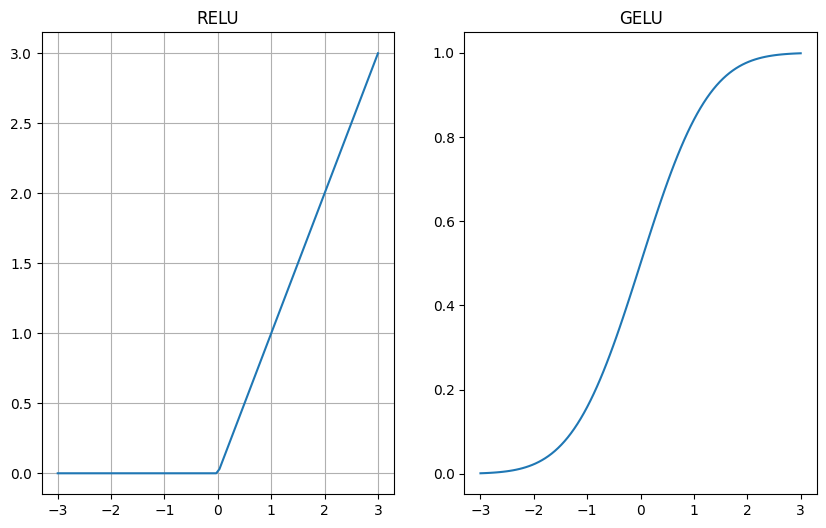

In [94]:
import matplotlib.pyplot as plt
x=torch.linspace(-3,3,100)
gelu,relu=GELU(),nn.ReLU()
y_gelu=gelu(x)
y_relu=relu(x)
plt.figure(figsize=(10,6))
plt.subplot(1,2,2)
plt.plot(x,y_gelu)
plt.title("GELU")
plt.subplot(1,2,1)
plt.plot(x,y_relu)
plt.title("RELU")
plt.grid(True)

plt.show()

In [95]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.layers = nn.Sequential(
      nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
      GELU(),
      nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
)
    def forward(self, x):
      return self.layers(x)

In [96]:
#now i will make the transformer class
class transformer(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(d_in=cfg["emb_dim"],d_out=cfg["emb_dim"],context_length=cfg["context_length"],num_heads=cfg["n_heads"],dropout=cfg["drop_rate"],qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_residual=nn.Dropout(cfg["drop_rate"])
  def forward(self,x):
    residual=x  #ADDING RESIDUAL CONNECTIONS FOR BETTER OPTIMIZATIONS
    x=self.att(x)
    x=self.drop_residual(x)
    x=x+residual
    residual=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_residual(x)
    x=x+residual
    return x

In [97]:
#NOW FINALLY WHOLE GPT MODEL
class GPT(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(
    *[transformer(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
    cfg["emb_dim"], cfg["vocab_size"], bias=False)
  def forward(self,in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
    torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [98]:
model=GPT(GPT_CONFIG_124M)

d_out must be divisible by num_heads
d_out must be divisible by num_heads


In [99]:
text = """Hello world. This is a tiny dataset.
Making GPT from scratch, now trying it out on this small dataset.I am trying to overfit my small model on this data just to check if it is working, then i will try to visualize attention mechanism."""

In [100]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")

tokens = enc.encode(text)
import torch
data = torch.tensor(tokens, dtype=torch.long)

In [101]:
enc.n_vocab

50257

In [102]:
block_size = 32

def get_batch(batch_size=4):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

In [111]:
#using smaller model , changed configurations
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

for step in range(200):
    xb, yb = get_batch()

    logits = model(xb)

    loss = torch.nn.functional.cross_entropy(
        logits.view(-1, logits.size(-1)),
        yb.view(-1)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(step, loss.item())

0 0.49344712495803833


In [105]:
xb, yb = get_batch()
logits = model(xb)

print("Input:", xb.shape)
print("Logits:", logits.shape)

Input: torch.Size([4, 32])
Logits: torch.Size([4, 32, 50257])


In [88]:
#NOW I WILL MAKE AN ATTENTION VISUALIZER
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    print("d_out must be divisible by num_heads")
    self.num_heads=num_heads
    self.d_out=d_out
    self.attn_weights=None #adding this
    self.dropout=nn.Dropout(dropout)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.head_dim=d_out//num_heads
    self.out_proj = nn.Linear(d_out, d_out)
    self.register_buffer(
    "mask",
    torch.triu(torch.ones(context_length, context_length),
               diagonal=1))
  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    keys=keys.transpose(1,2)
    values=values.transpose(1,2)
    queries=queries.transpose(1,2)
    attn_sc= queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_sc.masked_fill_(mask_bool, -torch.inf)
    attn_weights=torch.softmax(attn_sc/self.head_dim**0.5,dim=-1)
    self.attn_weights = attn_weights.detach()
    attn_weights=self.dropout(attn_weights)
    context_vec=attn_weights @ values
    context_vec=context_vec.transpose(1,2)
    context_vec = context_vec.contiguous().view(
    b, num_tokens, self.d_out
)
    context_vec = self.out_proj(context_vec)
    return context_vec

In [77]:
xb, yb = get_batch()
logits = model(xb)

In [113]:
torch.save(model.state_dict(), "model.pt")